In [1]:
from glob import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

accs = set()
methods = set()
result_all = defaultdict(dict)
result_7 = defaultdict(dict)
for fname in glob("*.csv"):
    acc, method = re.findall(r'(0\.\d+)_(.*)\.csv', fname)[0]
    acc = float(acc)
    df = pd.read_csv(fname)
    df = df.iloc[:,1:]

    # Total accuracy
    result_all[acc][method] = (df.sum(axis=1) >= 8).sum() / len(df)
    result_7[acc][method] = (df.sum(axis=1) >= 7).sum() / len(df)
    


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


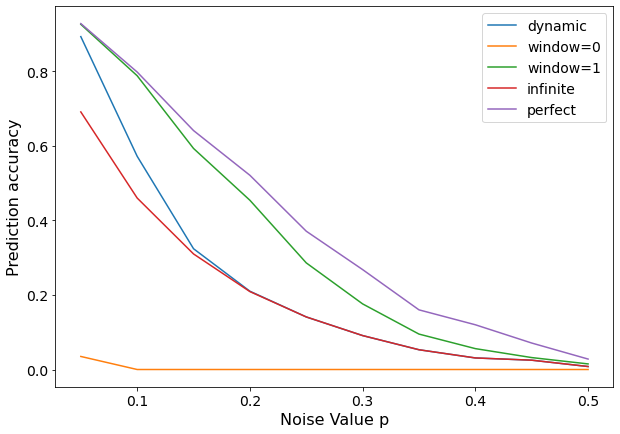

In [2]:

with plt.style.context('./arend.mplstyle'):
    
    ax = pd.DataFrame(result_7).T.sort_index().plot()
    ax.set_xlabel("Noise Value p")
    ax.set_ylabel("Prediction accuracy")
    ax.legend(["dynamic", "window=0", "window=1", "infinite", "perfect"])
    fig = ax.get_figure()
    fig.savefig("figures/DTW.pdf")
    fig.savefig("figures/DTW.eps")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


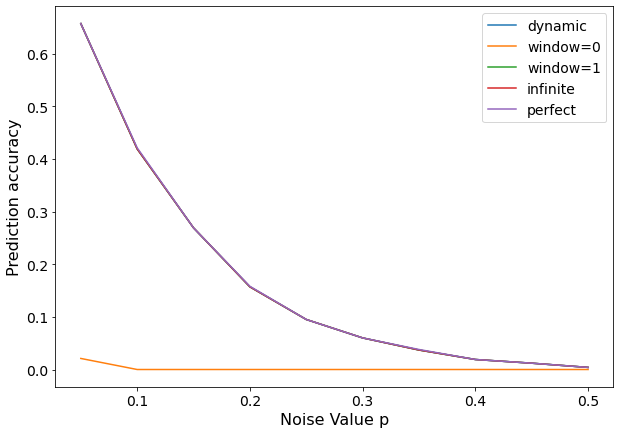

In [3]:

with plt.style.context('./arend.mplstyle'):
    
    ax = pd.DataFrame(result_all).T.sort_index().plot()
    ax.set_xlabel("Noise Value p")
    ax.set_ylabel("Prediction accuracy")
    ax.legend(["dynamic", "window=0", "window=1", "infinite", "perfect"])
    fig = ax.get_figure()
    fig.savefig("figures/DTW_full.pdf")
    fig.savefig("figures/DTW_full.eps")